In [18]:
from pulp import *

def solve_breakfast(w=500):
    prob = LpProblem("Optimal_Breakfast_Plan", LpMinimize)

    # Decision Variables
    # Main
    x1  = LpVariable("Tuna Mayo Triangle Kimbap",          cat="Binary")
    x2  = LpVariable("Milk Bread",           lowBound=0, upBound=150)
    x3  = LpVariable("Red Bean Bread",    cat="Binary")
    x4  = LpVariable("SweetPotato",     lowBound=0, upBound=200)
    # Drink
    x5  = LpVariable("Soy Milk",         cat="Binary")
    x6  = LpVariable("OrangeJuice",     cat="Binary")
    x7  = LpVariable("Milk",            cat="Binary")
    # Protein
    x8  = LpVariable("Soft Boiled Egg",             lowBound=0, upBound=2, cat="Integer")
    x9  = LpVariable("Chicken Breast Bar",      cat="Binary")
    x10 = LpVariable("Protein Bar",      cat="Binary")
    # Side
    x11 = LpVariable("Yogurt",          lowBound=0, upBound=200)
    x12 = LpVariable("Granola",         lowBound=0, upBound=50)
    x13 = LpVariable("Banana",          lowBound=0, upBound=2, cat="Integer")

    # Selection Variables for Big-M constraints
    y2  = LpVariable("Milk_Bread_sel",       cat="Binary")
    y4  = LpVariable("SweetPotato_sel", cat="Binary")
    y11 = LpVariable("Yogurt_sel",      cat="Binary")
    y12 = LpVariable("Granola_sel",     cat="Binary")

    # Calorie target and deviation variables
    cal_target = 450
    d_plus  = LpVariable("cal_over",  lowBound=0)
    d_minus = LpVariable("cal_under", lowBound=0)

    # Nutritional and cost coefficients for each food item(per unit)
    #            x1     x2      x3      x4     x5    x6    x7   x8    x9    x10   x11   x12    x13
    cal_c  = [ 205,   2.66,  250.0,  1.28,  95.0, 44.0, 135,  70,   130,  260,  0.70, 4.83,  105.0]
    carb_c = [  33,   0.47,  42.0,  0.3036,  4.0, 11.0,  10,   0,    3,   18,   0.05, 0.72,  26.95]
    pro_c  = [   5,   0.06,   7.0,  0.0172,  9.0,  0.0,   6,   6,   12,   14,   0.03, 0.06,   1.29]
    price_c= [1660,    6.9, 1232.5,  4.97, 657.4, 302.1, 536, 530, 1304, 1049,   3.8, 17.53,  349.0]

    vl = [x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13]
    n  = len(vl)

    cal_e  = lpSum(cal_c[i]  * vl[i] for i in range(n))
    carb_e = lpSum(carb_c[i] * vl[i] for i in range(n))
    pro_e  = lpSum(pro_c[i]  * vl[i] for i in range(n))
    cost_e = lpSum(price_c[i]* vl[i] for i in range(n))

    # Objective function: Minimize cost + penalty for calorie deviation
    prob += cost_e + w * (d_plus + d_minus), "Objective"

    # Constraints1: Total calories 300~600 kcal, with deviation from target 450 kcal
    prob += cal_e >= 300,                           "Calorie_Min"
    prob += cal_e <= 600,                           "Calorie_Max"
    prob += cal_e - d_plus + d_minus == cal_target, "Cal_Target"

    # Constraints2: Carbohydrates 50~65% of total calories (4 kcal/g)
    prob += carb_e * 4 >= 0.50 * cal_e,  "Carb_Min_50pct"
    prob += carb_e * 4 <= 0.65 * cal_e,  "Carb_Max_65pct"

    # Constraints3: Protein 10~20% of total calories (4 kcal/g)
    prob += pro_e * 4 >= 0.10 * cal_e,   "Protein_Min_10pct"
    prob += pro_e * 4 <= 0.20 * cal_e,   "Protein_Max_20pct"

    # Constraints4: Total cost 4,000~6,000 KRW
    prob += cost_e >= 4000,  "Budget_Min"
    prob += cost_e <= 6000,  "Budget_Max"

    # Constraints5: Exactly 1 main item (Big-M)
    prob += x1 + y2 + x3 + y4 == 1,  "Exactly_One_Main"

    # Constraints6: Exactly 1 drink (Big-M)
    prob += x5 + x6 + x7 == 1,       "Exactly_One_Drink"

    # Constraints7: At least 1 protein item (Big-M)
    prob += x8 + x9 + x10 >= 1,      "At_Least_One_Protein"

    # Constraints8: Big-M constraints to link selection variables with actual amounts
    # Yogurt and Granola must be selected together, and Granola must be at least 10g if selected
    prob += x2  <= 150 * y2,          "Bread_BigM"
    prob += x4  <= 200 * y4,          "SweetPotato_BigM"
    prob += x11 <= 300 * y11,         "Yogurt_BigM"
    prob += x12 <= 100 * y12,         "Granola_BigM"
    prob += y11 == y12,               "Yogurt_Granola_Set"
    prob += x12 >= 10 * y12,          "Granola_Min_Amount"

    # Solve
    status = prob.solve(PULP_CBC_CMD(msg=0))

    v = [x.varValue if x.varValue is not None else 0 for x in vl]
    total_cost = sum(price_c[i] * v[i] for i in range(n))
    total_cal  = sum(cal_c[i]   * v[i] for i in range(n))
    total_carb = sum(carb_c[i]  * v[i] for i in range(n))
    total_pro  = sum(pro_c[i]   * v[i] for i in range(n))

    return v, total_cost, total_cal, total_carb, total_pro, LpStatus[status]


# Run the optimization and print results
vals, cost, cal, carb, pro, status = solve_breakfast(w=500)

foods = [
    ("Shefood Tuna Mayo Triangle Kimbap", "Main",    f"{int(round(vals[0]))} item(s) (110g)",   vals[0]),
    ("Samlip Glutinous Milk Bread",       "Main",    f"{vals[1]:.1f} g",                        vals[1]),
    ("Red Bean Bread",                    "Main",    f"{int(round(vals[2]))} item(s) (85g)",     vals[2]),
    ("Sweet Potato",                      "Main",    f"{vals[3]:.1f} g",                        vals[3]),
    ("Maeil Soy Milk",                    "Drink",   f"{int(round(vals[4]))} pack(s) (190ml)",  vals[4]),
    ("Orange Juice",                      "Drink",   f"{int(round(vals[5]))} pack(s) (195ml)",  vals[5]),
    ("Seoul Milk",                        "Drink",   f"{int(round(vals[6]))} pack(s) (200ml)",  vals[6]),
    ("Bodeure Soft Boiled Egg",           "Protein", f"{int(round(vals[7]))} item(s) (50g)",    vals[7]),
    ("Chicken Breast Bar",                "Protein", f"{int(round(vals[8]))} item(s) (80g)",    vals[8]),
    ("Protein Bar",                       "Protein", f"{int(round(vals[9]))} item(s) (50g)",    vals[9]),
    ("Seoul Milk Pure Plain Yogurt",      "Side",    f"{vals[10]:.1f} ml",                      vals[10]),
    ("Market O Nature Granola",           "Side",    f"{vals[11]:.1f} g",                       vals[11]),
    ("Banana",                            "Side",    f"{int(round(vals[12]))} item(s) (100g)",  vals[12]),
]

print("=" * 60)
print("   Optimal Breakfast Plan (MIP Result)")
print("=" * 60)
print(f"  Status: {status}\n")

print(f"  {'Food':<36} {'Category':<10} {'Serving'}")
print(f"  {'-'*56}")
for name, cat, amt, val in foods:
    if val is not None and val > 1e-4:
        print(f"  {name:<36} {cat:<10} {amt}")

print(f"\n  {'─'*56}")
print(f"  {'Nutritional Summary':<30} {'Result':<15} {'Status'}")
print(f"  {'─'*56}")
print(f"  {'Calories (target: 450 kcal)':<30} {cal:<15.1f} {'✅' if 300 <= cal <= 600 else '❌'} (300~600)")
print(f"  {'Carbohydrates':<30} {carb*4/cal*100:<14.1f}% {'✅' if 49.9 <= carb*4/cal*100 <= 65.1 else '❌'} (50~65%)")
print(f"  {'Protein':<30} {pro*4/cal*100:<14.1f}% {'✅' if 10 <= pro*4/cal*100 <= 20 else '❌'} (10~20%)")
print(f"  {'Total Cost (KRW)':<30} {cost:<15.0f} {'✅' if 4000 <= cost <= 6000 else '❌'} (4,000~6,000)")
print(f"  {'─'*56}")

   Optimal Breakfast Plan (MIP Result)
  Status: Optimal

  Food                                 Category   Serving
  --------------------------------------------------------
  Shefood Tuna Mayo Triangle Kimbap    Main       1 item(s) (110g)
  Orange Juice                         Drink      1 pack(s) (195ml)
  Bodeure Soft Boiled Egg              Protein    1 item(s) (50g)
  Chicken Breast Bar                   Protein    1 item(s) (80g)
  Banana                               Side       1 item(s) (100g)

  ────────────────────────────────────────────────────────
  Nutritional Summary            Result          Status
  ────────────────────────────────────────────────────────
  Calories (target: 450 kcal)    554.0           ✅ (300~600)
  Carbohydrates                  53.4          % ✅ (50~65%)
  Protein                        17.5          % ✅ (10~20%)
  Total Cost (KRW)               4145            ✅ (4,000~6,000)
  ────────────────────────────────────────────────────────


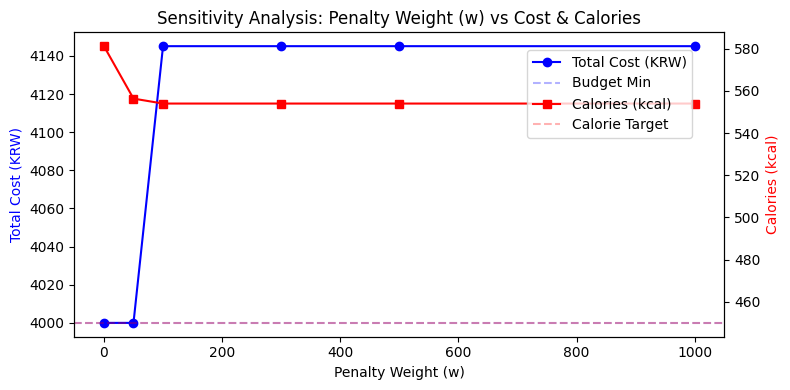

In [19]:
import matplotlib.pyplot as plt

w_values = [0, 50, 100, 300, 500, 1000]
results = []

for w in w_values:
    v, cost, cal, carb, pro, status = solve_breakfast(w=w)
    results.append({"w": w, "cost": cost, "cal": cal})

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot([r["w"] for r in results], [r["cost"] for r in results], 
         "bo-", label="Total Cost (KRW)")
ax2.plot([r["w"] for r in results], [r["cal"] for r in results],  
         "rs-", label="Calories (kcal)")

ax1.set_xlabel("Penalty Weight (w)")
ax1.set_ylabel("Total Cost (KRW)", color="blue")
ax2.set_ylabel("Calories (kcal)", color="red")
ax1.axhline(y=4000, color="blue", linestyle="--", alpha=0.3, label="Budget Min")
ax2.axhline(y=450,  color="red",  linestyle="--", alpha=0.3, label="Calorie Target")

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.title("Sensitivity Analysis: Penalty Weight (w) vs Cost & Calories")
plt.tight_layout()
plt.show()

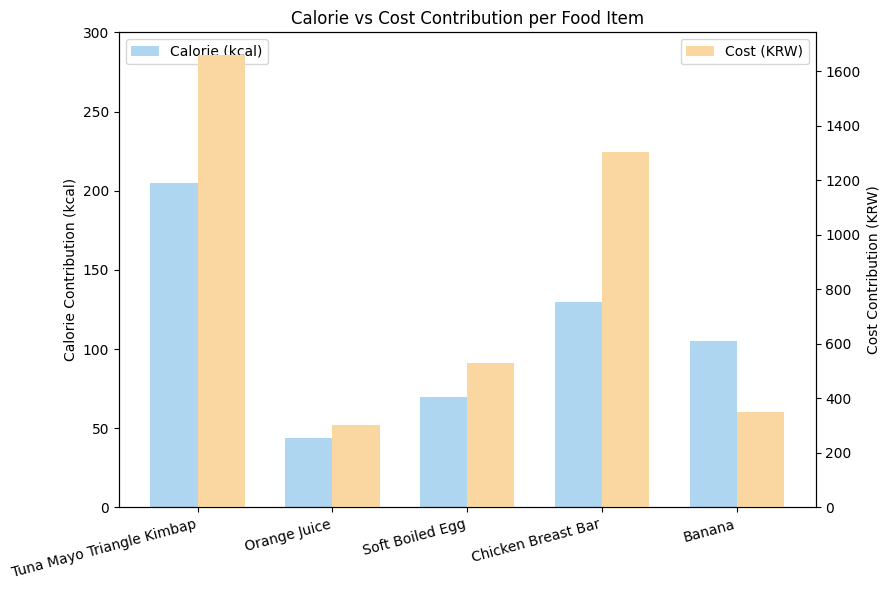

In [ ]:
food_names = [
    "Tuna Mayo Triangle Kimbap", "Milk Bread", "Red Bean Bread", "Sweet Potato",
    "Soy Milk", "Orange Juice", "Milk", "Soft Boiled Egg", "Chicken Breast Bar", "Protein Bar",
    "Yogurt", "Granola", "Banana"
]

cal_c  = [ 205,   2.66,  250.0,  1.28,  95.0, 44.0, 135,  70,   130,  260,  0.70, 4.83,  105.0]
price_c = [1660, 6.9, 1232.5, 4.97, 657.4, 302.1, 536, 530, 1304, 1049, 3.8, 17.53, 349.0]

# Filter only selected foods
selected_names   = []
cal_contrib      = []
cost_contrib     = []

for i, (name, val) in enumerate(zip(food_names, vals)):
    if val > 1e-4:
        selected_names.append(name)
        cal_contrib.append(cal_c[i] * val)
        cost_contrib.append(price_c[i] * val)

x     = range(len(selected_names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

ax1.bar([i - width/2 for i in x], cal_contrib,  width, label="Calorie (kcal)", color="#AED6F1")
ax2.bar([i + width/2 for i in x], cost_contrib, width, label="Cost (KRW)",     color="#FAD7A0")

ax1.set_ylabel("Calorie Contribution (kcal)")
ax2.set_ylabel("Cost Contribution (KRW)")
ax1.set_ylim(0, 300)
ax1.set_xticks(x)
ax1.set_xticklabels(selected_names, rotation=15, ha="right")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Calorie vs Cost Contribution per Food Item")
plt.tight_layout()
plt.show()